In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import sklearn
import seaborn as sns
from astropy.io import fits 
from astropy.table import Table

This notebook will feature the beginning stages of this project. The lightcurves and properties of a small set of variables will be explored and plotted here.

Data from the Zwicky Transiet Facility (ZTF) DR24 Archive is used. 

### List of variables used
1. Delta Cephei: 337.2927917 58.4151972 
2. Eta Aquilae: 298.1179167 1.0055556
3. Zeta Geminorum: 106.0272100 20.5703000
4. Mintaka: 83.0000000 0.0666667
5. W Ursae Majoris

In [ ]:
sample = ['delta_cephei','eta_aquilae','zeta_geminorum','mintaka','w_ursae_ma']

In [105]:
filename = "../data/raw/w_ursae_ma.fits"

hdul = fits.open(filename)
hdul.info()

Filename: ../data/raw/w_ursae_ma.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   ()      
  1  Table         1 BinTableHDU     81   16R x 24C   [1K, 1J, 1D, 1D, 1E, 1E, 1J, 2A, 1D, 1D, 1E, 1E, 1K, 1J, 1B, 1B, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1J]   


In [107]:
data = hdul[1].data

data

FITS_rec([(786111200028023, 68646636, 2458440.96796564, 58440.4663657, 17.489193, 0.02220161, 32768, 'zg', 145.9423688, 55.954684 ,  5.662,  0.009, 20181118466296, 786, 11, 2, 21.89, 26.181194, 0.03384057, -0.06138216, 2.85340757e-05, 30., 1.211, 3),
          (786111200028023, 71344268, 2458467.94602766, 58467.4426852, 16.720436, 0.01548343, 32768, 'zg', 145.9419596, 55.9550077,  6.921, -0.023, 20181215442662, 786, 11, 2, 20.53, 25.101501, 0.04428619, -0.04105809, 6.59099169e-05, 30., 1.107, 3),
          (786111200028023, 78636596, 2458540.86994704, 58540.3659606, 16.995028, 0.01730587, 0, 'zg', 145.9425045, 55.9548035, 10.95 ,  1.396, 20190226365949, 786, 11, 2, 21.8 , 26.303093, 0.02967529, -0.07857564, 2.20074216e-05, 30., 1.12 , 3),
          (786111200028023, 120820174, 2458962.70221058, 58962.2017477, 17.925026, 0.02896739, 0, 'zg', 145.9423439, 55.9548618,  3.666,  0.067, 20200423201713, 786, 11, 2, 21.73, 26.314703, 0.03351203, -0.07043709, 2.78133848e-05, 30., 1.108, 3),
   

In [84]:
data.names

['oid',
 'expid',
 'hjd',
 'mjd',
 'mag',
 'magerr',
 'catflags',
 'filtercode',
 'ra',
 'dec',
 'chi',
 'sharp',
 'filefracday',
 'field',
 'ccdid',
 'qid',
 'limitmag',
 'magzp',
 'magzprms',
 'clrcoeff',
 'clrcounc',
 'exptime',
 'airmass',
 'programid']

In [109]:
table = Table.read(filename, hdu=1)
df = table.to_pandas()

df.head()

,oid,expid,hjd,mjd,mag,magerr,catflags,filtercode,ra,dec,...,ccdid,qid,limitmag,magzp,magzprms,clrcoeff,clrcounc,exptime,airmass,programid
0,786111200028023,68646636,2.458441e+06,58440.466366,17.489193,0.022202,32768,b'zg',145.942369,55.954684,...,11,2,21.889999,26.181194,0.033841,-0.061382,0.000029,30.0,1.211,3
1,786111200028023,71344268,2.458468e+06,58467.442685,16.720436,0.015483,32768,b'zg',145.941960,55.955008,...,11,2,20.530001,25.101501,0.044286,-0.041058,0.000066,30.0,1.107,3
2,786111200028023,78636596,2.458541e+06,58540.365961,16.995028,0.017306,0,b'zg',145.942505,55.954803,...,11,2,21.799999,26.303093,0.029675,-0.078576,0.000022,30.0,1.120,3
3,786111200028023,120820174,2.458963e+06,58962.201748,17.925026,0.028967,0,b'zg',145.942344,55.954862,...,11,2,21.730000,26.314703,0.033512,-0.070437,0.000028,30.0,1.108,3
4,786111200028023,123217744,2.458987e+06,58986.177442,18.025513,0.030959,0,b'zg',145.942103,55.954976,...,11,2,21.709999,26.299461,0.027739,-0.048213,0.000019,30.0,1.182,3


In [110]:
df.columns

Index(['oid', 'expid', 'hjd', 'mjd', 'mag', 'magerr', 'catflags', 'filtercode',
       'ra', 'dec', 'chi', 'sharp', 'filefracday', 'field', 'ccdid', 'qid',
       'limitmag', 'magzp', 'magzprms', 'clrcoeff', 'clrcounc', 'exptime',
       'airmass', 'programid'],
      dtype='str')

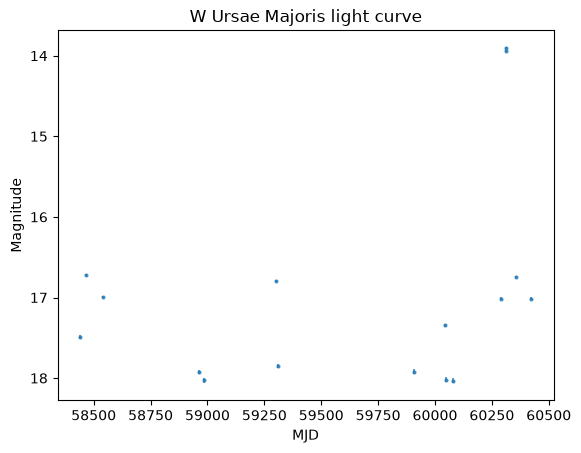

In [112]:
plt.errorbar(df["mjd"], df["mag"], yerr=df["magerr"],  fmt=".", markersize=4, alpha=0.7)

plt.xlabel("MJD")
plt.ylabel("Magnitude")
plt.title(r"W Ursae Majoris light curve")
plt.gca().invert_yaxis()
plt.savefig('../plots/00/w_ursae_ma_raw.png',dpi=300,bbox_inches='tight')
plt.show()

In [103]:
df["catflags"].value_counts()

catflags
0    4
Name: count, dtype: int64

In [89]:
clean = df[df["catflags"] == 0].copy()

In [90]:
print("Raw observations:", len(df))
print("Clean observations:", len(clean))

Raw observations: 93
Clean observations: 0


In [91]:
time = df["mjd"]
mag = df["mag"]

features = {
    "n_obs": len(df),
    "baseline_days": time.max() - time.min(),
    "mean_mag": mag.mean(),
    "median_mag": mag.median(),
    "std_mag": mag.std(),
    "min_mag": mag.min(),
    "max_mag": mag.max(),
    "amplitude_mag": mag.max() - mag.min(),
    "mad_mag": np.median(np.abs(mag - np.median(mag))),
}

print(features)

{'n_obs': 93, 'baseline_days': np.float64(1280.7087847000003), 'mean_mag': np.float32(13.976637), 'median_mag': np.float32(13.964389), 'std_mag': np.float32(0.18023129), 'min_mag': np.float32(13.440514), 'max_mag': np.float32(14.403918), 'amplitude_mag': np.float32(0.96340466), 'mad_mag': np.float32(0.11043358)}


In [59]:
features_array = []

In [92]:
features_array.append(features)

In [93]:
features_array

[{'n_obs': 343,
  'baseline_days': np.float64(2709.680161999997),
  'mean_mag': np.float32(14.612304),
  'median_mag': np.float32(14.599603),
  'std_mag': np.float32(0.3387862),
  'min_mag': np.float32(13.520762),
  'max_mag': np.float32(15.498443),
  'amplitude_mag': np.float32(1.9776802),
  'mad_mag': np.float32(0.22304916)},
 {'n_obs': 35,
  'baseline_days': np.float64(50.94442130000243),
  'mean_mag': np.float32(13.009855),
  'median_mag': np.float32(13.048312),
  'std_mag': np.float32(0.21339776),
  'min_mag': np.float32(12.653912),
  'max_mag': np.float32(13.474012),
  'amplitude_mag': np.float32(0.8201008),
  'mad_mag': np.float32(0.17076588)},
 {'n_obs': 93,
  'baseline_days': np.float64(1280.7087847000003),
  'mean_mag': np.float32(13.976637),
  'median_mag': np.float32(13.964389),
  'std_mag': np.float32(0.18023129),
  'min_mag': np.float32(13.440514),
  'max_mag': np.float32(14.403918),
  'amplitude_mag': np.float32(0.96340466),
  'mad_mag': np.float32(0.11043358)}]

In [104]:
hdul.close()

In [94]:
features_df = pd.DataFrame(features_array)

In [95]:
features_df

,n_obs,baseline_days,mean_mag,median_mag,std_mag,min_mag,max_mag,amplitude_mag,mad_mag
0,343,2709.680162,14.612304,14.599603,0.338786,13.520762,15.498443,1.977680,0.223049
1,35,50.944421,13.009855,13.048312,0.213398,12.653912,13.474012,0.820101,0.170766
2,93,1280.708785,13.976637,13.964389,0.180231,13.440514,14.403918,0.963405,0.110434


In [ ]:
#Inserting Samples to beginning of dataframe 

In [ ]:
#features_df.insert(loc=0, column='samples', value=samples)